Before proceeding with things, I want to know for sure the functionality of a time distributed layer. What does this layer do exactly, how to make sense out of this. The most commno encounter with this is in Numerical Machine Translation problems, where the Dense layer with softmax actiavation is wrapped in a TimeDistributed layer as the decoder outputs are a time series.

But what exactly happens here?

In [1]:
import tensorflow as tf
import numpy as np

2025-07-10 11:04:11.646900: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-10 11:04:11.682822: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-10 11:04:11.682846: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-10 11:04:11.683781: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-10 11:04:11.690038: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Below is the keras example - It cosiders 32 video samples, each video is 10 frames, each frame is a 128,128,3 RGB image.

# For the time distributed layer - The input should be at least 3D, and the index = 1 should correspond to the time dimension

inputs = tf.keras.layers.Input(shape = (10,128,128,3), batch_size = 32)

conv2D_layer = tf.keras.layers.Conv2D(64, (3,3))

output = tf.keras.layers.TimeDistributed(conv2D_layer)(inputs)

2025-07-10 11:04:13.512874: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:86:00.0, compute capability: 7.0


In [3]:
example_model1 = tf.keras.models.Model(inputs = inputs, outputs = output)

In [4]:
example_model1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(32, 10, 128, 128, 3)]   0         
                                                                 
 time_distributed (TimeDist  (32, 10, 126, 126, 64)    1792      
 ributed)                                                        
                                                                 
Total params: 1792 (7.00 KB)
Trainable params: 1792 (7.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


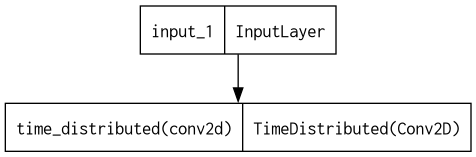

In [5]:
tf.keras.utils.plot_model(example_model1)

In [6]:
# there's 3 layers and then the bias
(3*3*64) * 3 + 64

1792

In [7]:
inputs.shape

TensorShape([32, 10, 128, 128, 3])

In [8]:
output.shape

TensorShape([32, 10, 126, 126, 64])

In [9]:
# can we do the same architecture but without the timedistributed layer?

In [10]:
inputs_example2 = tf.keras.layers.Input(shape = (10,128,128,3), batch_size = 32)

conv2D_layer = tf.keras.layers.Conv2D(64, (3,3))

output_output = conv2D_layer(inputs_example2)

In [11]:
output_output.shape

TensorShape([32, 10, 126, 126, 64])

In [12]:
example_model2 = tf.keras.models.Model(inputs = inputs_example2, outputs = output_output)

In [13]:
example_model2.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(32, 10, 128, 128, 3)]   0         
                                                                 
 conv2d_1 (Conv2D)           (32, 10, 126, 126, 64)    1792      
                                                                 
Total params: 1792 (7.00 KB)
Trainable params: 1792 (7.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


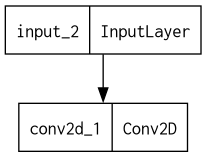

In [14]:
tf.keras.utils.plot_model(example_model2)

In [15]:
# Seems both these work -  should we train these models for a few epochs and see if we can get the same results?

In [16]:
# layer weights model 1

In [17]:
conv_layer_weights_ex1 = conv2D_layer.get_weights()

In [18]:
len(conv_layer_weights_ex1)

2

In [19]:
conv_layer_weights_ex1[0].shape, conv_layer_weights_ex1[1].shape

((3, 3, 3, 64), (64,))

In [20]:
# layer weights model 2

In [21]:
conv_layer_weights_ex2 = conv2D_layer.get_weights()

In [22]:
len(conv_layer_weights_ex2)

2

In [23]:
conv_layer_weights_ex2[0].shape, conv_layer_weights_ex2[1].shape

((3, 3, 3, 64), (64,))

In [24]:
# are these identical? since we are doing default initializers?
print(np.mean(conv_layer_weights_ex1[0] == conv_layer_weights_ex2[0]))
print(np.mean(conv_layer_weights_ex1[0] == conv_layer_weights_ex2[0]))

1.0
1.0


In [25]:
# generate some random values for input and output?

X_train = np.random.normal(loc=2, scale=3, size=(32, 10, 128, 128, 3))
y_train = np.random.random(size = (32, 10, 126, 126, 64))

In [26]:
X_train.shape

(32, 10, 128, 128, 3)

In [27]:
y_train.shape

(32, 10, 126, 126, 64)

In [28]:
# train the first model

# compile the model
example_model1.compile(optimizer = "adam", loss = 'mse', metrics = ['mae'])

In [29]:
example_model1.fit(X_train, y_train, epochs = 20)

Epoch 1/20


2025-07-10 11:04:21.117494: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-07-10 11:04:22.140084: I external/local_xla/xla/service/service.cc:168] XLA service 0x14beed2bd000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-10 11:04:22.140115: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-07-10 11:04:22.145624: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1752163462.246558 3962491 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 [==============================] - 3s 3s/step - loss: 1.4574 - mae: 0.9678
Epoch 2/20
1/1 [==============================] - 0s 341ms/step - loss: 1.3851 - mae: 0.9418
Epoch 3/20
1/1 [==============================] - 0s 332ms/step - loss: 1.3173 - mae: 0.9170
Epoch 4/20
1/1 [==============================] - 0s 335ms/step - loss: 1.2540 - mae: 0.8934
Epoch 5/20
1/1 [==============================] - 0s 368ms/step - loss: 1.1949 - mae: 0.8710
Epoch 6/20
1/1 [==============================] - 0s 328ms/step - loss: 1.1399 - mae: 0.8498
Epoch 7/20
1/1 [==============================] - 0s 359ms/step - loss: 1.0889 - mae: 0.8298
Epoch 8/20
1/1 [==============================] - 0s 352ms/step - loss: 1.0415 - mae: 0.8109
Epoch 9/20
1/1 [==============================] - 0s 357ms/step - loss: 0.9978 - mae: 0.7932
Epoch 10/20
1/1 [==============================] - 0s 328ms/step - loss: 0.9574 - mae: 0.7766
Epoch 11/20
1/1 [==============================] - 0s 360ms/step - loss: 0.9201 - m

In [30]:
# weights of the trained first model for the conv layer
traied_conv_layer_weights_ex1 = example_model1.layers[1].get_weights()

In [31]:
traied_conv_layer_weights_ex1[0].shape, traied_conv_layer_weights_ex1[1].shape

((3, 3, 3, 64), (64,))

In [32]:
# train the secons model

# compile the model
example_model2.compile(optimizer = "adam", loss = 'mse', metrics = ['mae'])

In [33]:
example_model2.fit(X_train, y_train, epochs = 20)

Epoch 1/20
1/1 [==============================] - 2s 2s/step - loss: 1.5017 - mae: 0.9778
Epoch 2/20
1/1 [==============================] - 0s 332ms/step - loss: 1.4250 - mae: 0.9501
Epoch 3/20
1/1 [==============================] - 0s 338ms/step - loss: 1.3536 - mae: 0.9240
Epoch 4/20
1/1 [==============================] - 0s 347ms/step - loss: 1.2874 - mae: 0.8994
Epoch 5/20
1/1 [==============================] - 0s 335ms/step - loss: 1.2262 - mae: 0.8764
Epoch 6/20
1/1 [==============================] - 0s 360ms/step - loss: 1.1700 - mae: 0.8549
Epoch 7/20
1/1 [==============================] - 0s 350ms/step - loss: 1.1184 - mae: 0.8350
Epoch 8/20
1/1 [==============================] - 0s 350ms/step - loss: 1.0712 - mae: 0.8166
Epoch 9/20
1/1 [==============================] - 0s 337ms/step - loss: 1.0280 - mae: 0.7995
Epoch 10/20
1/1 [==============================] - 0s 327ms/step - loss: 0.9884 - mae: 0.7837
Epoch 11/20
1/1 [==============================] - 0s 358ms/step - loss:

In [34]:
# weights of the trained first model for the conv layer
traied_conv_layer_weights_ex2 = example_model2.layers[1].get_weights()

In [35]:
traied_conv_layer_weights_ex2[0].shape, traied_conv_layer_weights_ex2[1].shape

((3, 3, 3, 64), (64,))

In [36]:
# are these weights the same?
np.mean(traied_conv_layer_weights_ex2[0] == traied_conv_layer_weights_ex1[0])

0.0

In [37]:
# none of these are the same, I think this is to be expected. 

In [38]:
# traied_conv_layer_weights_ex2[0]

In [39]:
# but can we do a get weights and set weights from model 1 to 2?

In [40]:
example_model2.set_weights(example_model1.get_weights())

In [41]:
# so yes, this can be done

In [42]:
np.mean(example_model2.get_weights()[0] == traied_conv_layer_weights_ex1[0])

1.0

In [44]:
# What I want to know exactly is how does the back prop work in these two instances? Maybe need to learn this with a simpler example.